In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score, precision_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [52]:
df = pd.read_csv('dataset.csv')
df.columns = [i for i in range(df.shape[1])]
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.393380,0.584782,1.979943e-07,0.424767,0.523391,0.006182,0.432338,0.460242,0.016973,0.423576,...,0.316589,0.435906,0.021481,0.329957,0.450646,0.023204,0.341009,0.473203,0.026340,a
1,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,a
2,0.439547,0.612854,8.552769e-08,0.481858,0.638530,-0.031760,0.531156,0.629996,-0.044338,0.566044,...,0.502156,0.477896,-0.027956,0.496457,0.505605,-0.028312,0.487302,0.527840,-0.022726,a
3,0.438298,0.625916,1.226611e-08,0.486782,0.608649,-0.012231,0.528449,0.564092,-0.013198,0.547334,...,0.445950,0.455228,-0.007722,0.447425,0.483462,-0.003152,0.444719,0.505180,0.003771,a
4,0.399578,0.632239,2.661281e-07,0.440506,0.579357,0.001057,0.454733,0.523016,0.003472,0.459908,...,0.354225,0.472250,-0.010379,0.366656,0.461965,-0.009942,0.378702,0.462762,-0.008425,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.367940,0.597239,1.529477e-07,0.412350,0.548001,-0.007376,0.430737,0.487734,-0.003891,0.429133,...,0.325808,0.453558,0.019775,0.332413,0.469937,0.019824,0.338169,0.488895,0.022840,a
95,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,a
96,0.431888,0.601697,-1.083485e-07,0.485071,0.607812,-0.016077,0.528281,0.591319,-0.019126,0.556334,...,0.490611,0.447004,0.001295,0.480228,0.470944,0.002478,0.470975,0.490961,0.009034,a
97,0.438436,0.603508,-1.331962e-08,0.489904,0.566118,-0.000863,0.521163,0.516888,0.004026,0.531274,...,0.435013,0.435363,0.010534,0.437316,0.460436,0.014560,0.435746,0.480369,0.022421,a


In [53]:
df = df.rename(columns={63: 'Output'})
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,Output
0,0.393380,0.584782,1.979943e-07,0.424767,0.523391,0.006182,0.432338,0.460242,0.016973,0.423576,...,0.316589,0.435906,0.021481,0.329957,0.450646,0.023204,0.341009,0.473203,0.026340,a
1,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,a
2,0.439547,0.612854,8.552769e-08,0.481858,0.638530,-0.031760,0.531156,0.629996,-0.044338,0.566044,...,0.502156,0.477896,-0.027956,0.496457,0.505605,-0.028312,0.487302,0.527840,-0.022726,a
3,0.438298,0.625916,1.226611e-08,0.486782,0.608649,-0.012231,0.528449,0.564092,-0.013198,0.547334,...,0.445950,0.455228,-0.007722,0.447425,0.483462,-0.003152,0.444719,0.505180,0.003771,a
4,0.399578,0.632239,2.661281e-07,0.440506,0.579357,0.001057,0.454733,0.523016,0.003472,0.459908,...,0.354225,0.472250,-0.010379,0.366656,0.461965,-0.009942,0.378702,0.462762,-0.008425,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.367940,0.597239,1.529477e-07,0.412350,0.548001,-0.007376,0.430737,0.487734,-0.003891,0.429133,...,0.325808,0.453558,0.019775,0.332413,0.469937,0.019824,0.338169,0.488895,0.022840,a
95,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,a
96,0.431888,0.601697,-1.083485e-07,0.485071,0.607812,-0.016077,0.528281,0.591319,-0.019126,0.556334,...,0.490611,0.447004,0.001295,0.480228,0.470944,0.002478,0.470975,0.490961,0.009034,a
97,0.438436,0.603508,-1.331962e-08,0.489904,0.566118,-0.000863,0.521163,0.516888,0.004026,0.531274,...,0.435013,0.435363,0.010534,0.437316,0.460436,0.014560,0.435746,0.480369,0.022421,a


In [54]:
X = df.iloc[:, :-1]
print("Features shape =", X.shape)

Y = df.iloc[:, -1]
print("Labels shape =", Y.shape)

Features shape = (99, 63)
Labels shape = (99,)


In [55]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
svm = SVC(C=10, gamma=0.1, kernel='rbf')
svm.fit(x_train, y_train)

ValueError: The number of classes has to be greater than one; got 1 class

In [56]:
y_pred = svm.predict(x_test)
y_pred

AttributeError: 'SVC' object has no attribute 'support_vectors_'

In [58]:
cf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
precision = precision_score(y_test, y_pred, average='micro')
f1, recall, precision

NameError: name 'y_pred' is not defined

NameError: name 'cf_matrix' is not defined

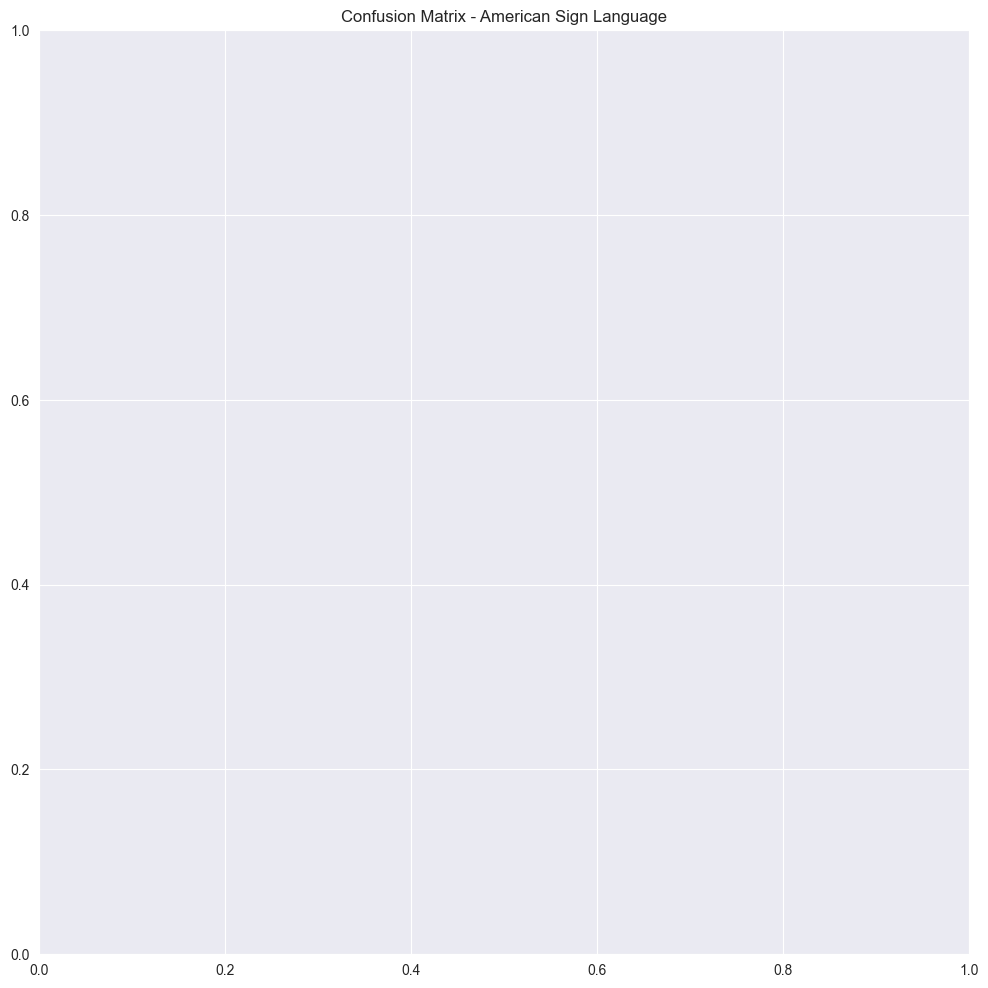

In [59]:
labels = sorted(list(set(df['Output'])))
labels = [x.upper() for x in labels]

fig, ax = plt.subplots(figsize=(12, 12))

ax.set_title("Confusion Matrix - American Sign Language")

maping = sns.heatmap(cf_matrix, 
                     annot=True,
                     cmap = plt.cm.Blues, 
                     linewidths=.2,
                     xticklabels=labels,
                     yticklabels=labels, vmax=8,
                     fmt='g',
                     ax=ax
                    )
maping

In [60]:
import pickle

# save model
with open('model.pkl','wb') as f:
    pickle.dump(svm,f)